In [1]:
import sys
sys.path.append('..')
from src.config import BASE_MODEL, CHECKPOINTS, checkpoint
from src.refusal_alignment import run_alignment, alignment_table, plot_alignment
from datasets import load_dataset

forget_prompts = [ex["question"] for ex in load_dataset("locuslab/TOFU","forget10")["train"]]


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/tofu_Llama-3.2-1B-Instruct_full
Device: mps | dtype: torch.float16
Params: 1.2B
v3 built at layer 14: refused=35, complied=15, raw_norm=3.629
control direction built at layer 14: 25 vs 25 harmless prompts (no refusal signal by design)


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_GradDiff_lr1e-05_alpha5_epoch5
Device: mps | dtype: torch.float16
Params: 1.2B
GradDiff  cos=+0.106 |cos|=0.106 ctrl=+0.186 ABOVE floor


...

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_SimNPO_lr2e-05_b4.5_a1_d1_g0.125_ep10
Device: mps | dtype: torch.float16
Params: 1.2B
SimNPO    cos=+0.127 |cos|=0.127 ctrl=+0.202 ABOVE floor


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded: open-unlearning/unlearn_tofu_Llama-3.2-1B-Instruct_forget10_RMU_lr5e-05_layer10_scoeff10_epoch10
Device: mps | dtype: torch.float16
Params: 1.2B
RMU       cos=+0.076 |cos|=0.076 ctrl=+0.143 ABOVE floor

Layer 14  —  v3 refusal direction vs unlearning mean-offset
random-Gaussian floor (too permissive): mean|cos|=0.018  p99=0.054
------------------------------------------------------------------------
method       v3 cos    |v3|  ctrl cos  |ctrl|         verdict
GradDiff     +0.106   0.106    +0.186   0.186       = control
NPO          +0.008   0.008    +0.087   0.087       = control
AltPO        +0.092   0.092    +0.158   0.158       = control
SimNPO       +0.127   0.127    +0.202   0.202       = control
RMU          +0.076   0.076    +0.143   0.143       = control
------------------------------------------------------------------------
sign check: 5/5 cosines positive. ALL same sign -> shared offset component (confound signal).
=> No method's v3 alignment beats the refusal-free

<Axes: title={'center': 'Refusal-direction alignment with unlearning shift  (layer 14)\nv3 vs a refusal-FREE control against the same offsets:\nif the bars match, the alignment is shared structure, not refusal'}, ylabel='|cosine with unlearning mean-offset|'>

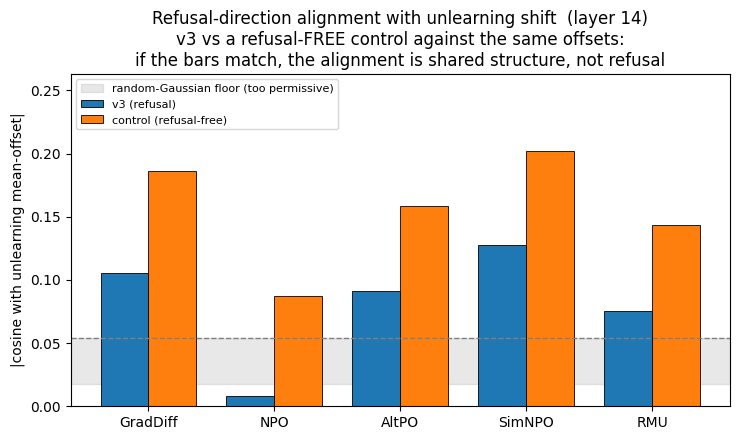

In [2]:
res = run_alignment(
    layer=14,
    base_model_id=BASE_MODEL,
    method_ids={m: checkpoint(m) for m in CHECKPOINTS},
    forget_prompts=forget_prompts,
    labeled_csv="../results/cleaned_harmful_harmless_responses_labeled.csv",
)
alignment_table(res)
plot_alignment(res)